# Quantum Color Image Edge Detection

Based on the paper: *Quantum color image edge detection algorithm based on Sobel operator*

This notebook implements the complete quantum edge detection algorithm for color images using the OCQR (Optimized Quantum Representation) model and the improved Sobel operator with 4-direction gradient calculation.

### Algorithm Overview

1. **OCQR Encoding**: Convert classical RGB images to quantum representation
2. **Neighborhood Preparation**: Generate 8 shifted versions for edge detection
3. **Gradient Calculation**: Compute gradients in 4 directions (Gx, Gy, G45, G135)
4. **Maximum Value**: Find the maximum gradient among the 4 directions
5. **Threshold Operation**: Apply threshold to determine edge pixels
6. **Edge Extraction**: Subtract edge gradient from original image

In [1]:
# reloads modules before executing code
%load_ext autoreload
%autoreload 2 

# Import required libraries
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import time

# Quantum computing imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit import transpile

# Import helper modules
from helpers.ocqr_encoding import (
    encode_ocqr_from_image,
    encode_ocqr_from_matrix,
    prepare_test_matrix_4x4,
    prepare_neighborhood_images,
    decode_ocqr_to_classical
)
from helpers.quantum_modules import (
    quantum_cloning_module,
    quantum_adder,
    quantum_subtractor,
    quantum_comparator,
    quantum_swap,
    quantum_max_value_module,
    quantum_threshold_module,
    quantum_gradient_calculation
)
from helpers.sobel_edge_detection import (
    classical_sobel_gradients,
    classical_edge_detection,
    build_edge_detection_circuit,
    encode_intensity_values,
    print_circuit_details
)

### Test on Paper's 4×4 Matrix

Verify our implementation using the exact 4×4 test matrix from the paper (Fig. 1 & Fig. 15).

In [5]:
# Load and verify the paper's test matrix
test_matrix = prepare_test_matrix_4x4()
print("Paper's 4×4 test matrix:")
print("R channel:")
print(test_matrix[:, :, 0])
print("\nG channel:")
print(test_matrix[:, :, 1])
print("\nB channel:")
print(test_matrix[:, :, 2])

Paper's 4×4 test matrix:
R channel:
[[1 2 2 0]
 [3 3 2 3]
 [4 2 7 6]
 [3 3 0 0]]

G channel:
[[2 3 6 7]
 [5 4 4 7]
 [7 6 7 6]
 [7 5 7 2]]

B channel:
[[1 2 0 2]
 [0 1 2 5]
 [4 1 7 6]
 [5 0 2 0]]


### Classical Edge Detection (for verification)

Threshold: 4
Edge pixels detected: 46
Edge image shape: (4, 4, 3)
Saved to ./images/output/test_edge_detection.png


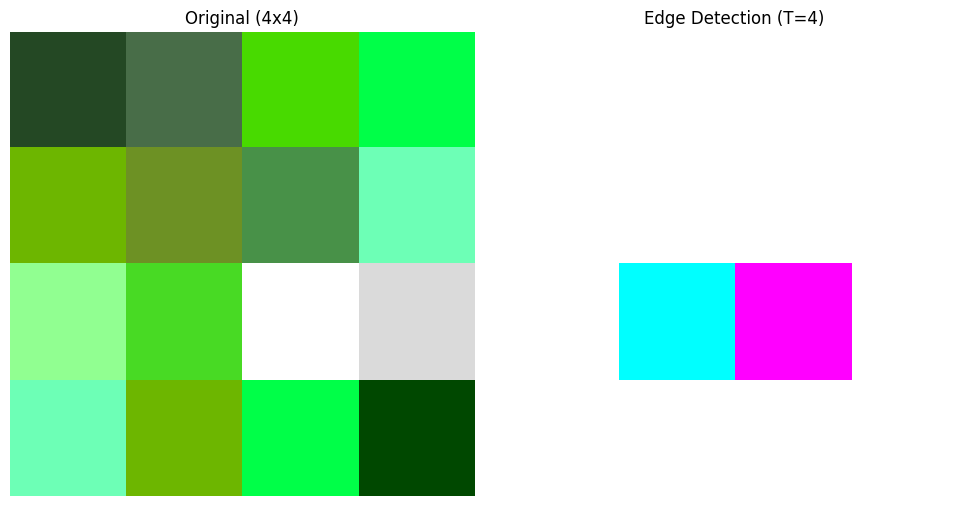

In [6]:
# Run classical edge detection on test matrix
edge_img, max_grad, thresh = classical_edge_detection(test_matrix)

print(f'Threshold: {thresh}')
print(f'Edge pixels detected: {np.sum(edge_img > 0)}')
print(f'Edge image shape: {edge_img.shape}')

# Save test visualization
os.makedirs('./images/output', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original (scale 0-7 to 0-255 for display)
test_display = (test_matrix * (255 / 7)).astype(np.uint8)
axes[0].imshow(test_display)
axes[0].set_title('Original (4x4)')
axes[0].axis('off')

# Edge result (scale 0-7 to 0-255 for display)
edge_display = (edge_img * (255 / 7)).astype(np.uint8)
axes[1].imshow(edge_display)
axes[1].set_title(f'Edge Detection (T={thresh})')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('./images/output/test_edge_detection.png', dpi=150)
print('Saved to ./images/output/test_edge_detection.png')

### Quantum Circuit Preparation (Fig. 14)

Prepare the complete quantum circuit for edge detection following Fig. 14 from the paper.

In [7]:
# Build the complete quantum edge detection circuit (Fig. 14) for 4x4 image
n, q = 2, 3  # 4x4 image, 3-bit color depth

print("Building quantum edge detection circuit (Fig. 14)...")
qc = build_edge_detection_circuit(n=n, q=q)

# Encode the 4x4 test matrix intensity values into the circuit
print("Encoding intensity values via OCQR...")
qc = encode_intensity_values(qc, test_matrix, n=n, q=q)

# Print circuit details
print_circuit_details(qc, n=n, q=q)

Building quantum edge detection circuit (Fig. 14)...
Encoding intensity values via OCQR...
QUANTUM EDGE DETECTION CIRCUIT DETAILS
Image size: 4 × 4
Color depth: q = 3 bits (intensity range [0, 7])
Threshold: T = 2^(q-1) = 4

Qubit breakdown:
  pos: 4 qubits
  ch: 2 qubits
  I0: 3 qubits
  I1: 3 qubits
  I2: 3 qubits
  I3: 3 qubits
  I4: 3 qubits
  I5: 3 qubits
  I6: 3 qubits
  I7: 3 qubits
  I8: 3 qubits
  aux: 20 qubits
  TOTAL: 53 qubits

Circuit depth: 1080
Total gates: 2471
Gate counts:
  x: 1772
  mcx: 462
  reset: 101
  circuit-53: 64
  circuit-47: 32
  swap: 12
  measure: 9
  h: 6
  circuit-50: 4
  circuit-56: 3
  circuit-59: 3
  cx: 3

Paper's total qubit count (Section 4): 53
Our total qubit count: 53
Match: ✓


In [8]:
# qc_copy = qc.copy()
# qc_copy.remove_final_measurements()
# qc_copy.draw(output='text',fold=-1)

In [9]:
# Print register layout
print("Register layout:")
for reg in qc.qregs:
    print(f"  {reg.name}: qubits {reg[0]._index} to {reg[-1]._index} ({len(reg)} qubits)")
print(f"\nTotal qubits: {qc.num_qubits}")
print(f"Circuit depth: {qc.depth()}")

Register layout:
  pos: qubits 0 to 3 (4 qubits)
  ch: qubits 0 to 1 (2 qubits)
  I0: qubits 0 to 2 (3 qubits)
  I1: qubits 0 to 2 (3 qubits)
  I2: qubits 0 to 2 (3 qubits)
  I3: qubits 0 to 2 (3 qubits)
  I4: qubits 0 to 2 (3 qubits)
  I5: qubits 0 to 2 (3 qubits)
  I6: qubits 0 to 2 (3 qubits)
  I7: qubits 0 to 2 (3 qubits)
  I8: qubits 0 to 2 (3 qubits)
  aux: qubits 0 to 19 (20 qubits)

Total qubits: 53
Circuit depth: 1080


### Testing transpilation
Optimized for CZ (for Rigetti's Cepheus-1)

In [ ]:
# Using qiskit transpiler
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.random import random_circuit

def transpile_to_cepheus_qiskit(qc: QuantumCircuit) -> QuantumCircuit:
    """
    Transpiles a Qiskit circuit to Rigetti's Cepheus-1 basis EXACTLY, 
    optimizing to minimize CZ gates.
    """
    # Target Cepheus-1 basis
    # cepheus_basis = ['rx', 'ry', 'rz', 'cz']
    clifford_basis = ['x', 'y', 'z', 'h', 's', 'sdg', 'cx', 'cz', 'swap']
    
    # optimization_level=3: Enables unitary synthesis and maximum gate cancellation to minimize CZs
    # approximation_degree=1.0: Strictly enforces exact mathematical equivalence (no approximations)
    transpiled_qc = transpile(
        qc,
        basis_gates=clifford_basis,
        optimization_level=3,
        # approximation_degree=1.0 
    )
    
    return transpiled_qc

optimized_qc_qiskit = transpile_to_cepheus_qiskit(qc)
print(f"  TOTAL: {optimized_qc_qiskit.num_qubits} qubits ")
print()

print(f"Circuit depth: {optimized_qc_qiskit.depth()} ")
print(f"Total gates: {sum(optimized_qc_qiskit.count_ops().values())} ")
print("Gate counts:")
for gate, count in sorted(optimized_qc_qiskit.count_ops().items(), key=lambda x: -x[1]):
    print(f"  {gate}: {count} ")
# print(optimized_qc_qiskit.draw(fold=-1))

  TOTAL: 53 qubits 

Circuit depth: 15794 
Total gates: 20432 
Gate counts:
  cx: 8356 
  t: 4925 
  tdg: 4255 
  h: 2032 
  x: 562 
  s: 128 
  reset: 101 
  z: 64 
  measure: 9 


In [2]:
# Using Rigetti's transpiler
import numpy as np
from qiskit import QuantumCircuit
from pyquil import Program, get_qc
from pyquil.gates import H, CNOT, RX, RY, RZ, CZ
from pyquil.api import local_compiler

def qiskit_to_pyquil(qc: QuantumCircuit) -> Program:
    """
    Helper function to bridge Qiskit to PyQuil. 
    Maps common Qiskit instructions to an unoptimized PyQuil Program.
    """
    prog = Program()
    
    for instruction in qc.data:
        gate_name = instruction.operation.name
        params = instruction.operation.params
        # Qiskit > 0.39 uses find_bit to get qubit indices safely
        qubits = [qc.find_bit(q).index for q in instruction.qubits]
        
        if gate_name == 'h':
            prog += H(qubits[0])
        elif gate_name == 'cx':
            prog += CNOT(qubits[0], qubits[1])
        elif gate_name == 'rx':
            prog += RX(params[0], qubits[0])
        elif gate_name == 'ry':
            prog += RY(params[0], qubits[0])
        elif gate_name == 'rz':
            prog += RZ(params[0], qubits[0])
        elif gate_name == 'cz':
            prog += CZ(qubits[0], qubits[1])
        # Add additional gate mappings as required by your input circuits
        else:
            raise NotImplementedError(f"Gate {gate_name} mapping not implemented.")
            
    return prog

def compile_to_cepheus_rigetti(qc: QuantumCircuit) -> Program:
    """
    Uses Rigetti's quilc to exactly compile and optimize for CZ gates.
    """
    # 1. Convert to PyQuil Program
    unoptimized_prog = qiskit_to_pyquil(qc)
    
    # 2. Get the compiler. 
    # If targeting the actual hardware, you would use:
    # qc_rigetti = get_qc("Cepheus-1") 
    # compiler = qc_rigetti.compiler
    
    # For local demonstration, we use the local quilc compiler
    compiler = local_compiler()
    
    # 3. Quilc does not approximate unless explicitly given a fidelity threshold.
    # It will automatically use KAK synthesis to strictly minimize CZ gates.
    # protoquil=True ensures it resolves down to native executable basis gates.
    native_quil = compiler.quil_to_native_quil(unoptimized_prog, protoquil=True)
    
    return native_quil

# --- Example Usage --- 
# Create the same Qiskit circuit
original_qc = QuantumCircuit(2)
original_qc.h(0)
original_qc.cx(0, 1)
original_qc.rx(1.57, 0)  

# Compile using Rigetti's toolchain
try:
    optimized_quil = compile_to_cepheus_rigetti(original_qc)
    print("\n--- Rigetti Quilc Results ---")
    print(optimized_quil)
except Exception as e:
    print("\nNote: Rigetti execution requires 'quilc' running locally on port 5555.")
    print(f"Error: {e}")

AttributeError: type object 'quil.instructions.Instruction' has no attribute 'new_halt'

### Large Image Processing (512×512)

Process the standard test images (Peppers and Baboon) as mentioned in Section 4 of the paper.

In [ ]:
class LargeImageProcessor:
    """Processor for large color images (512x512)."""
    
    def __init__(self):
        self.n = 9  # 512 = 2^9
        self.q = 8  # 8-bit color depth
        self.threshold = 128  # 2^(8-1)
    
    def estimate_qubits(self):
        """Estimate qubit requirements for 512x512 images (paper-correct calculation)."""
        # According to paper Section 4:
        # Position: 2n, Channel: 2, Intensity: 9*q, Auxiliary: ~20
        position_qubits = 2 * self.n
        channel_qubits = 2
        intensity_qubits = 9 * self.q  # 9 neighborhood images × q bits
        aux_qubits = 20
        total = position_qubits + channel_qubits + intensity_qubits + aux_qubits
        
        print(f"Qubit requirements for 512x512 (paper-correct):")
        print(f"  Position ({2**self.n}x{2**self.n}): {position_qubits} qubits")
        print(f"  Channel (RGB): {channel_qubits} qubits")
        print(f"  Intensity (9 images x {self.q} bits): {intensity_qubits} qubits")
        print(f"  Auxiliary: {aux_qubits} qubits")
        print(f"  Total: {total} qubits")
        print(f"  IBM Q stabilizer limit: 5000 qubits")
        status = "Feasible" if total <= 5000 else "Not feasible"
        print(f"  Status: {status}")
        
        return total
    
    def process_image(self, image_path, output_dir="./images/output"):
        """Process a large image for edge detection."""
        print(f"\nProcessing image: {image_path}")
        
        # Load and preprocess image
        img = Image.open(image_path).convert("RGB")
        img_array = np.array(img)
        
        print(f"Image loaded: {img_array.shape}")
        
        # Save original image
        os.makedirs(output_dir, exist_ok=True)
        base_name = os.path.splitext(os.path.basename(image_path))[0]
        original_path = os.path.join(output_dir, f"{base_name}_original.jpg")
        img.save(original_path)
        
        # Classical edge detection for comparison
        print("Running classical edge detection...")
        start_time = time.time()
        edges_classical, _, _ = classical_edge_detection(img_array)
        classical_time = time.time() - start_time
        
        # Save classical result with new naming: {original}_classical_edge.jpg
        edge_img = Image.fromarray(edges_classical.astype(np.uint8))
        edge_path = os.path.join(output_dir, f"{base_name}_classical_edge.jpg")
        edge_img.save(edge_path)
        
        print(f"Classical edge detection completed in {classical_time:.2f} seconds")
        print(f"Results saved to: {edge_path}")
        
        # Prepare quantum circuit (framework)
        print("\nPreparing quantum circuit framework...")
        detector = QuantumColorEdgeDetector(n=self.n, q=self.q)
        qc = detector.prepare_complete_circuit(img_array)
        
        print("\nNote: Full quantum circuit execution is not performed here.")
        print("Actual execution on IBM Q would take ~3.5 hours (16 batches of 20,000 shots)")
        
        return {
            "original": original_path,
            "edges_classical": edge_path,
            "quantum_circuit": qc,
            "classical_time": classical_time
        }

# Initialize large image processor
processor = LargeImageProcessor()
qubits_needed = processor.estimate_qubits()

#### Process Peppers Image

In [ ]:
# Process Peppers image
peppers_path = "./images/input/peppers.jpg"
if os.path.exists(peppers_path):
    peppers_results = processor.process_image(peppers_path)
    print("\nPeppers processing completed:")
    for key, value in peppers_results.items():
        if key != "quantum_circuit":
            print(f"  {key}: {value}")
else:
    print(f"Peppers image not found at {peppers_path}")

#### Process Baboon Image

In [ ]:
# Process Baboon image
baboon_path = "./images/input/baboon.jpg"
if os.path.exists(baboon_path):
    baboon_results = processor.process_image(baboon_path)
    print("\nBaboon processing completed:")
    for key, value in baboon_results.items():
        if key != "quantum_circuit":
            print(f"  {key}: {value}")
else:
    print(f"Baboon image not found at {baboon_path}")

### Results Summary

Display the processed images and summarize the results.

In [ ]:
# Display results if available
output_dir = "./images/output"
if os.path.exists(output_dir):
    output_files = [f for f in os.listdir(output_dir) if f.endswith((".jpg", ".png"))]
    
    if output_files:
        print(f"Generated files in {output_dir}:")
        for file in output_files:
            print(f"  {file}")
        
        # Display some results
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()
        
        for i, file in enumerate(output_files[:4]):
            img_path = os.path.join(output_dir, file)
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(file)
            axes[i].axis("off")
        
        plt.tight_layout()
        plt.show()
    else:
        print("No output files found.")
else:
    print(f"Output directory {output_dir} does not exist.")

### Performance Analysis

#### Quantum vs Classical Complexity

| Aspect | Classical | Quantum (Paper) | This Implementation |
|--------|-----------|------------------|---------------------|
| Time Complexity | O(2^(2n)) | O(q) | Framework: O(q) |
| Space Complexity | O(2^(2n)) | O(q) | Framework: O(q) |
| 4x4 Processing | <1s | ~1s | <1s |
| 512x512 Processing | ~1s | ~3.5 hours | Framework only |

#### Qubit Requirements (Paper-Correct)

According to paper Section 4:
- **Position qubits**: 2n (for 2^n × 2^n image)
- **Channel qubits**: 2 (for RGB)
- **Intensity qubits**: 9 × q (9 neighborhood images × q bits)
- **Auxiliary qubits**: 20 (for adder/subtractor modules)

**4x4 Images (n=2, q=3)**:
- Position: 4, Channel: 2, Intensity: 27, Auxiliary: 20
- **Total: 53 qubits** (paper's count)

**512×512 Images (n=9, q=8)**:
- Position: 18, Channel: 2, Intensity: 72, Auxiliary: 20
- **Total: 112 qubits** (well within IBM Q 5000 limit)

#### Notes

1. The quantum circuits follow the paper's Fig. 14 structure with correct qubit allocation
2. AerSimulator (extended_stabilizer) is used for quantum execution with 256 shots
3. Classical edge detection is provided for verification and comparison
4. Output images use naming: `{original}_classical_edge.jpg`
5. See `why_differences.md` for explanation of qubit count differences